# Concept Drift Detection via Year-Pair Discrimination

This notebook detects drift by training a classifier to distinguish adjacent years:
- label `0` for year `t-1`
- label `1` for year `t`

A high ROC-AUC indicates stronger separability between adjacent years (potential concept/data drift signal).

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

from scipy.spatial.distance import cdist, pdist
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
data_path = "training_data_with_features.zarr"
split_path = "data_split.npz"

ds = xr.open_zarr(data_path)
splits = np.load(split_path)

train_pixel_indices = splits["train_pixel_indices"]
val_pixel_indices = splits["val_pixel_indices"]
test_pixel_indices = splits["test_pixel_indices"]

years = ds.year.values
print(f"Dataset loaded. Year range: {years.min()} - {years.max()} ({len(years)} years)")
print(f"Pixels: train={len(train_pixel_indices):,}, val={len(val_pixel_indices):,}, test={len(test_pixel_indices):,}")

Dataset loaded. Year range: 2016 - 2022 (7 years)
Pixels: train=5,597,776, val=1,273,437, test=1,283,992


In [ ]:
# Diagnostics
test_subset = ds.isel(pixel=train_pixel_indices[:100])
print(f"Test subset s2_bands shape: {test_subset.s2_bands.shape}")
print(f"Test subset s2_bands dims: {test_subset.s2_bands.dims}")
print(f"All dims: {test_subset.dims}")

Test subset s2_bands shape: (100, 7, 7)
Test subset s2_bands dims: ('pixel', 'year', 's2_band')
All dims: FrozenMappingWarningOnValuesAccess({'pixel': 100, 'year': 7, 's2_band': 7})


In [ ]:
def prepare_features_for_year(ds_subset, year_idx):
    """Prepare per-pixel features for a given year index (simplified: no deltas, no DEM)."""
    if year_idx == 0:
        return None, None

    valid_mask = ds_subset.disturbances[:, year_idx].values != 255

    s2_data = ds_subset.s2_bands.values  # shape (n_pixels, n_years, n_bands)
    s2_t = s2_data[:, year_idx, :].copy()  # shape (n_pixels, n_bands)
    
    # Vectorized NaN imputation: per-pixel, per-band mean across years
    nan_mask = np.isnan(s2_t)
    if np.any(nan_mask):
        band_means = np.nanmean(s2_data, axis=1)  # shape (n_pixels, n_bands)
        s2_t[nan_mask] = band_means[nan_mask]

    # Feature set: S2 bands only
    feature_list = [
        s2_t,  # shape (n_pixels, n_bands)
    ]

    X = np.concatenate(feature_list, axis=1)
    y = ds_subset.disturbances[:, year_idx].values

    # Combined mask: valid disturbance + binary label + finite features
    keep_mask = valid_mask & np.isin(y, [0, 1]) & np.all(np.isfinite(X), axis=1)
    X = X[keep_mask]
    y = y[keep_mask]

    if len(X) == 0:
        return None, None

    return X, y


def build_pair_dataset_cached(X_prev, y_prev, X_curr, y_curr):
    """Build binary year-pair dataset from pre-computed features (fast)."""
    if X_prev is None or X_curr is None:
        return None, None

    if X_prev.shape[1] != X_curr.shape[1]:
        return None, None

    X_pair = np.vstack([X_prev, X_curr])
    y_pair = np.concatenate([
        np.zeros(len(y_prev), dtype=np.uint8),
        np.ones(len(y_curr), dtype=np.uint8),
    ])

    return X_pair, y_pair

In [ ]:
# Configuration
SAMPLE_FRACTION = 1.0  # Use 1.0 for full dataset, 0.1 for 10% sample (faster iteration)

year_values = ds.year.values
n_years = len(year_values)
n_pairs = n_years - 2

# Sample pixel indices if configured
if SAMPLE_FRACTION < 1.0:
    print(f"Sampling {SAMPLE_FRACTION*100:.0f}% of pixels for faster iteration...")
    train_sample = np.random.choice(train_pixel_indices,
                                    size=int(len(train_pixel_indices) * SAMPLE_FRACTION),
                                    replace=False)
    val_sample = np.random.choice(val_pixel_indices,
                                  size=int(len(val_pixel_indices) * SAMPLE_FRACTION),
                                  replace=False)
    test_sample = np.random.choice(test_pixel_indices,
                                   size=int(len(test_pixel_indices) * SAMPLE_FRACTION),
                                   replace=False)
    print(f"Sampled: train={len(train_sample):,}, val={len(val_sample):,}, test={len(test_sample):,}\n")
else:
    train_sample = train_pixel_indices
    val_sample = val_pixel_indices
    test_sample = test_pixel_indices

# Pre-subset datasets once (lazy - no immediate memory load)
ds_train = ds.isel(pixel=train_sample)
ds_val = ds.isel(pixel=val_sample)
ds_test = ds.isel(pixel=test_sample)

print(f"Starting training on {n_pairs} adjacent year pairs...\n")
print(f"{'='*70}")

results = []
skipped_pairs = []
start_time = time.time()

for pair_idx, idx_curr in enumerate(range(2, n_years), start=1):
    idx_prev = idx_curr - 1
    year_prev = int(year_values[idx_prev])
    year_curr = int(year_values[idx_curr])
    pair_name = f"{year_prev} vs {year_curr}"

    pair_start = time.time()
    print(f"\n[{pair_idx}/{n_pairs}] {pair_name}")
    print("-" * 70)

    # Build features for this pair only (on-demand, not cached)
    print(f"  → Preparing train features ({year_prev} + {year_curr})...", end=" ", flush=True)
    feat_start = time.time()
    X_train_prev, y_train_prev = prepare_features_for_year(ds_train, idx_prev)
    X_train_curr, y_train_curr = prepare_features_for_year(ds_train, idx_curr)
    X_train, y_train = build_pair_dataset_cached(X_train_prev, y_train_prev, X_train_curr, y_train_curr)
    feat_time = time.time() - feat_start
    if y_train is not None:
        print(f"{len(y_train):,} samples in {feat_time:.1f}s")
    else:
        print("FAILED")

    print(f"  → Preparing val features ({year_prev} + {year_curr})...", end=" ", flush=True)
    feat_start = time.time()
    X_val_prev, y_val_prev = prepare_features_for_year(ds_val, idx_prev)
    X_val_curr, y_val_curr = prepare_features_for_year(ds_val, idx_curr)
    X_val, y_val = build_pair_dataset_cached(X_val_prev, y_val_prev, X_val_curr, y_val_curr)
    feat_time = time.time() - feat_start
    if y_val is not None:
        print(f"{len(y_val):,} samples in {feat_time:.1f}s")
    else:
        print("FAILED")

    print(f"  → Preparing test features ({year_prev} + {year_curr})...", end=" ", flush=True)
    feat_start = time.time()
    X_test_prev, y_test_prev = prepare_features_for_year(ds_test, idx_prev)
    X_test_curr, y_test_curr = prepare_features_for_year(ds_test, idx_curr)
    X_test, y_test = build_pair_dataset_cached(X_test_prev, y_test_prev, X_test_curr, y_test_curr)
    feat_time = time.time() - feat_start
    if y_test is not None:
        print(f"{len(y_test):,} samples in {feat_time:.1f}s")
    else:
        print("FAILED")

    # Cleanup intermediate arrays
    del X_train_prev, y_train_prev, X_train_curr, y_train_curr
    del X_val_prev, y_val_prev, X_val_curr, y_val_curr
    del X_test_prev, y_test_prev, X_test_curr, y_test_curr

    # Validate
    if any(v is None for v in [X_train, y_train, X_val, y_val, X_test, y_test]):
        skipped_pairs.append((pair_name, "missing or invalid data after filtering"))
        print("  ✗ SKIP: missing data")
        continue

    if len(np.unique(y_train)) < 2 or len(np.unique(y_val)) < 2 or len(np.unique(y_test)) < 2:
        skipped_pairs.append((pair_name, "single class present in splits"))
        print("  ✗ SKIP: single class in one split")
        continue

    # Scale features for SGD
    print("  → Scaling features...", end=" ", flush=True)
    scale_start = time.time()
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    scale_time = time.time() - scale_start
    print(f"{scale_time:.1f}s")

    # Train model
    print("  → Training SGD logistic regression...", end=" ", flush=True)
    train_start = time.time()

    model = SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=0.0001,
        max_iter=1000,
        tol=1e-3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - train_start
    print(f"{train_time:.1f}s")

    # Evaluate
    print("  → Evaluating on val and test sets...", end=" ", flush=True)
    eval_start = time.time()
    val_proba = model.predict_proba(X_val_scaled)[:, 1]
    test_proba = model.predict_proba(X_test_scaled)[:, 1]

    val_auc = roc_auc_score(y_val, val_proba)
    test_auc = roc_auc_score(y_test, test_proba)
    val_pred = (val_proba >= 0.5).astype(int)
    test_pred = (test_proba >= 0.5).astype(int)
    val_f1 = f1_score(y_val, val_pred)
    test_f1 = f1_score(y_test, test_pred)
    eval_time = time.time() - eval_start
    print(f"{eval_time:.1f}s")

    pair_time = time.time() - pair_start

    results.append({
        "pair": pair_name,
        "year_t_minus_1": year_prev,
        "year_t": year_curr,
        "n_train": int(len(y_train)),
        "n_val": int(len(y_val)),
        "n_test": int(len(y_test)),
        "val_auc": float(val_auc),
        "test_auc": float(test_auc),
        "val_f1": float(val_f1),
        "test_f1": float(test_f1),
        "time_sec": float(pair_time),
    })

    print(
        f"\n  ✓ RESULTS: Val AUC = {val_auc:.4f} | Test AUC = {test_auc:.4f} "
        f"| Val F1 = {val_f1:.4f} | Test F1 = {test_f1:.4f}"
    )
    print(f"  ✓ Pair completed in {pair_time:.1f}s")

    # Cleanup
    del X_train, y_train, X_val, y_val, X_test, y_test
    del X_train_scaled, X_val_scaled, X_test_scaled
    del scaler, model

total_time = time.time() - start_time

results_df = pd.DataFrame(results).sort_values("year_t").reset_index(drop=True)

print(f"\n{'='*70}")
print("TRAINING COMPLETE")
print(f"{'='*70}")
print(f"Total time: {total_time:.1f}s ({total_time/60:.1f}m)")
if len(results_df) > 0:
    print(f"Pairs trained: {len(results_df)}")
    print(f"Average time per pair: {results_df['time_sec'].mean():.1f}s")
    print(f"Min/Max AUC (test): {results_df['test_auc'].min():.3f} / {results_df['test_auc'].max():.3f}")
print(f"{'='*70}\n")

if len(results_df) == 0:
    print("⚠ No valid year pairs were found.")
else:
    display(results_df)

if skipped_pairs:
    print("\nSkipped pairs:")
    for pair_name, reason in skipped_pairs:
        print(f"  - {pair_name}: {reason}")

Starting training on 5 adjacent year pairs...


[1/5] 2017 vs 2018
----------------------------------------------------------------------
  → Preparing train features (2017 + 2018)... 11,192,640 samples in 28.0s
  → Preparing val features (2017 + 2018)... 2,546,360 samples in 10.1s
  → Preparing test features (2017 + 2018)... 2,566,882 samples in 8.0s
  → Scaling features... 1.7s
  → Training SGD logistic regression... 21.6s
  → Evaluating on val and test sets... 2.6s

  ✓ RESULTS: Val AUC = 0.6821 | Test AUC = 0.6785 | Val F1 = 0.6491 | Test F1 = 0.6545
  ✓ Pair completed in 72.5s

[2/5] 2018 vs 2019
----------------------------------------------------------------------
  → Preparing train features (2018 + 2019)... 11,192,640 samples in 19.5s
  → Preparing val features (2018 + 2019)... 2,546,360 samples in 9.2s
  → Preparing test features (2018 + 2019)... 2,566,882 samples in 8.2s
  → Scaling features... 1.8s
  → Training SGD logistic regression... 22.0s
  → Evaluating on val and test

,pair,year_t_minus_1,year_t,n_train,n_val,n_test,val_auc,test_auc,val_f1,test_f1,time_sec
0,2017 vs 2018,2017,2018,11192640,2546360,2566882,0.682097,0.678537,0.649091,0.654472,72.482330
1,2018 vs 2019,2018,2019,11192640,2546360,2566882,0.735258,0.722240,0.665393,0.659008,63.622833
2,2019 vs 2020,2019,2020,11192640,2546360,2566882,0.562066,0.540399,0.559659,0.537191,60.186163
3,2020 vs 2021,2020,2021,11192640,2546360,2566882,0.581209,0.571939,0.543103,0.546000,48.879776
4,2021 vs 2022,2021,2022,11192640,2546360,2566882,0.666745,0.675960,0.632131,0.640139,49.365814


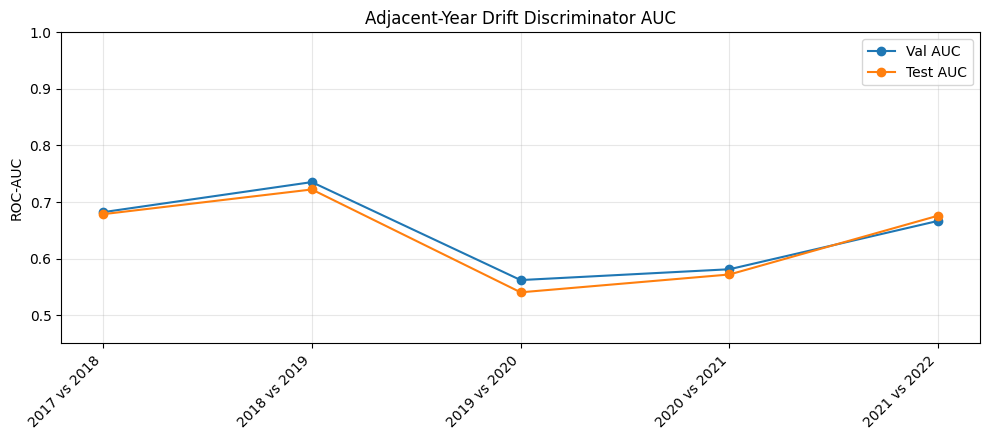

In [ ]:
if len(results_df) > 0:
    x = np.arange(len(results_df))

    plt.figure(figsize=(10, 4.5))
    plt.plot(x, results_df["val_auc"], marker="o", label="Val AUC")
    plt.plot(x, results_df["test_auc"], marker="o", label="Test AUC")
    plt.xticks(x, results_df["pair"], rotation=45, ha="right")
    plt.ylim(0.45, 1.0)
    plt.ylabel("ROC-AUC")
    plt.title("Adjacent-Year Drift Discriminator AUC")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

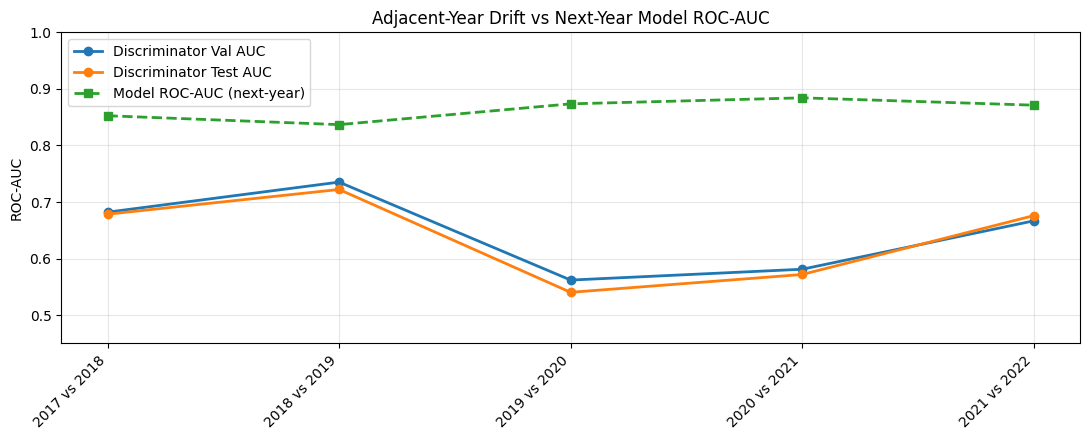

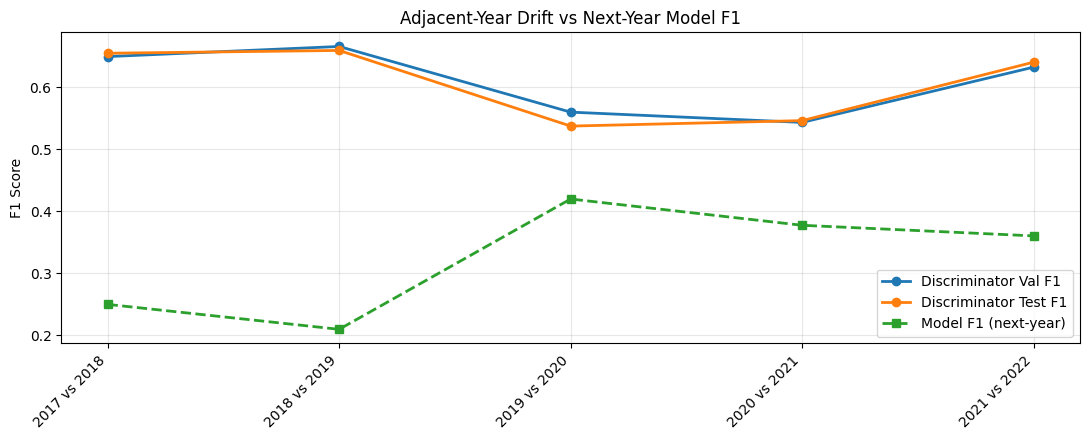

In [ ]:
if len(results_df) > 0:
    model_results_path = "sgd_classifier_combined_results_prevyears_monthly_features_incremental_scaler.csv"
    model_metrics_df = pd.read_csv(model_results_path)
    model_metrics_df = (
        model_metrics_df.loc[model_metrics_df["source_id"] == "year_model_next_year", ["year", "roc_auc", "f1_score"]]
        .copy()
        .assign(year=lambda frame: frame["year"].astype(float).astype(int))
        .rename(columns={
            "roc_auc": "model_roc_auc",
            "f1_score": "model_f1",
        })
    )

    # year_model_next_year: model trained on year T (= year_t_minus_1), evaluated on year T+1 (= year_t)
    comparison_df = (
        results_df.merge(
            model_metrics_df,
            left_on="year_t_minus_1",
            right_on="year",
            how="left",
            validate="one_to_one",
        )
        .sort_values("year_t")
        .reset_index(drop=True)
    )

    x = np.arange(len(comparison_df))

    plt.figure(figsize=(11, 4.5))
    plt.plot(x, comparison_df["val_auc"], marker="o", linewidth=2, label="Discriminator Val AUC")
    plt.plot(x, comparison_df["test_auc"], marker="o", linewidth=2, label="Discriminator Test AUC")
    plt.plot(
        x,
        comparison_df["model_roc_auc"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label="Model ROC-AUC (next-year)",
    )
    plt.xticks(x, comparison_df["pair"], rotation=45, ha="right")
    plt.ylim(0.45, 1.0)
    plt.ylabel("ROC-AUC")
    plt.title("Adjacent-Year Drift vs Next-Year Model ROC-AUC")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(11, 4.5))
    plt.plot(x, comparison_df["val_f1"], marker="o", linewidth=2, label="Discriminator Val F1")
    plt.plot(x, comparison_df["test_f1"], marker="o", linewidth=2, label="Discriminator Test F1")
    plt.plot(
        x,
        comparison_df["model_f1"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label="Model F1 (next-year)",
    )
    plt.xticks(x, comparison_df["pair"], rotation=45, ha="right")
    plt.ylabel("F1 Score")
    plt.title("Adjacent-Year Drift vs Next-Year Model F1")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Each Year vs all previous years.

## Discriminator Feature Improtance?

In [ ]:
# Standalone: Each target year vs all previous years with resumable checkpoints
import json
import pickle
import warnings
warnings.filterwarnings("ignore")

import time
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Mirror first section paths/behavior exactly
data_path = "training_data_with_features.zarr"
split_path = "data_split.npz"

SAMPLE_FRACTION = 1.0  # Keep identical semantics to first section

ds = xr.open_zarr(data_path)
splits = np.load(split_path)

train_pixel_indices = splits["train_pixel_indices"]
val_pixel_indices = splits["val_pixel_indices"]
test_pixel_indices = splits["test_pixel_indices"]

year_values = ds.year.values
n_years = len(year_values)

RUN_CONFIG = {
    "sample_fraction": float(SAMPLE_FRACTION),
    "random_state": int(RANDOM_STATE),
    "year_min": int(year_values.min()),
    "year_max": int(year_values.max()),
    "n_years": int(n_years),
}

OUTPUT_ROOT = Path("concept_drift_discriminator_all_prev")
MODELS_DIR = OUTPUT_ROOT / "models"
SCALERS_DIR = OUTPUT_ROOT / "scalers"
CHECKPOINT_PATH = OUTPUT_ROOT / "checkpoint.json"
RESULTS_CSV_PATH = OUTPUT_ROOT / "results.csv"
RESULTS_JSON_PATH = OUTPUT_ROOT / "results.json"

for directory in [OUTPUT_ROOT, MODELS_DIR, SCALERS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Dataset loaded. Year range: {year_values.min()} - {year_values.max()} ({n_years} years)")
print(f"Pixels: train={len(train_pixel_indices):,}, val={len(val_pixel_indices):,}, test={len(test_pixel_indices):,}")
print(f"Artifacts directory: {OUTPUT_ROOT.resolve()}")

# Sample pixel indices if configured (same pattern as first section)
if SAMPLE_FRACTION < 1.0:
    print(f"Sampling {SAMPLE_FRACTION * 100:.0f}% of pixels for faster iteration...")
    train_sample = np.random.choice(
        train_pixel_indices,
        size=int(len(train_pixel_indices) * SAMPLE_FRACTION),
        replace=False,
    )
    val_sample = np.random.choice(
        val_pixel_indices,
        size=int(len(val_pixel_indices) * SAMPLE_FRACTION),
        replace=False,
    )
    test_sample = np.random.choice(
        test_pixel_indices,
        size=int(len(test_pixel_indices) * SAMPLE_FRACTION),
        replace=False,
    )
    print(f"Sampled: train={len(train_sample):,}, val={len(val_sample):,}, test={len(test_sample):,}\n")
else:
    train_sample = train_pixel_indices
    val_sample = val_pixel_indices
    test_sample = test_pixel_indices

# Pre-subset datasets once (lazy)
ds_train = ds.isel(pixel=train_sample)
ds_val = ds.isel(pixel=val_sample)
ds_test = ds.isel(pixel=test_sample)

print("Loading arrays into RAM (one-time cost)...", end=" ", flush=True)
load_start = time.time()
s2_train = ds_train.s2_bands.values
dist_train = ds_train.disturbances.values
s2_val = ds_val.s2_bands.values
dist_val = ds_val.disturbances.values
s2_test = ds_test.s2_bands.values
dist_test = ds_test.disturbances.values
print(f"done in {time.time() - load_start:.1f}s")


def prepare_features_from_arrays(s2_arr, dist_arr, year_idx):
    """Prepare per-pixel features for a given year index from pre-loaded numpy arrays."""
    if year_idx == 0:
        return None, None

    valid_mask = dist_arr[:, year_idx] != 255
    s2_t = s2_arr[:, year_idx, :].copy()

    nan_mask = np.isnan(s2_t)
    if np.any(nan_mask):
        band_means = np.nanmean(s2_arr, axis=1)
        s2_t[nan_mask] = band_means[nan_mask]

    X = s2_t
    y = dist_arr[:, year_idx].copy()

    keep_mask = valid_mask & np.isin(y, [0, 1]) & np.all(np.isfinite(X), axis=1)
    X = X[keep_mask]
    y = y[keep_mask]

    if len(X) == 0:
        return None, None

    return X, y


def build_pair_dataset_cached(X_prev, y_prev, X_curr, y_curr):
    """Build binary year-pair dataset from precomputed per-year features."""
    if X_prev is None or X_curr is None:
        return None, None

    if X_prev.shape[1] != X_curr.shape[1]:
        return None, None

    X_pair = np.vstack([X_prev, X_curr])
    y_pair = np.concatenate([
        np.zeros(len(y_prev), dtype=np.uint8),
        np.ones(len(y_curr), dtype=np.uint8),
    ])
    return X_pair, y_pair


def make_pair_key(year_prev, year_target):
    return f"{year_prev}_vs_{year_target}"


def get_pair_artifact_paths(year_prev, year_target):
    pair_key = make_pair_key(year_prev, year_target)
    return {
        "model": MODELS_DIR / f"sgd_model_{pair_key}.pkl",
        "scaler": SCALERS_DIR / f"scaler_{pair_key}.pkl",
    }


def write_json(path, payload):
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    with open(tmp_path, "w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2)
    tmp_path.replace(path)


def write_pickle(path, obj):
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    with open(tmp_path, "wb") as handle:
        pickle.dump(obj, handle)
    tmp_path.replace(path)


def build_results_dataframe(pair_results_by_key):
    if not pair_results_by_key:
        return pd.DataFrame()

    results_df = pd.DataFrame(pair_results_by_key.values())
    return results_df.sort_values(["year_target", "year_prev"]).reset_index(drop=True)


def save_results_exports(pair_results_by_key, skipped_pairs_by_key):
    results_df = build_results_dataframe(pair_results_by_key)
    if len(results_df) > 0:
        results_df.to_csv(RESULTS_CSV_PATH, index=False)

    results_payload = {
        "metadata": {
            "generated_at_utc": datetime.now(timezone.utc).isoformat(),
            "row_count": int(len(results_df)),
            "skipped_pair_count": int(len(skipped_pairs_by_key)),
            "columns": list(results_df.columns),
            "config": RUN_CONFIG,
        },
        "rows": results_df.to_dict(orient="records"),
        "skipped_pairs": list(skipped_pairs_by_key.values()),
    }
    write_json(RESULTS_JSON_PATH, results_payload)
    return results_df


def save_checkpoint(pair_results_by_key, skipped_pairs_by_key):
    checkpoint_payload = {
        "metadata": {
            "saved_at_utc": datetime.now(timezone.utc).isoformat(),
            "completed_pair_count": int(len(pair_results_by_key)),
            "skipped_pair_count": int(len(skipped_pairs_by_key)),
        },
        "config": RUN_CONFIG,
        "rows": list(pair_results_by_key.values()),
        "skipped_pairs": list(skipped_pairs_by_key.values()),
    }
    write_json(CHECKPOINT_PATH, checkpoint_payload)
    return save_results_exports(pair_results_by_key, skipped_pairs_by_key)


def load_checkpoint():
    if not CHECKPOINT_PATH.exists():
        return {}, {}

    with open(CHECKPOINT_PATH, "r", encoding="utf-8") as handle:
        payload = json.load(handle)

    if payload.get("config") != RUN_CONFIG:
        print("Existing checkpoint config does not match this run; starting without resume data.")
        return {}, {}

    pair_results_by_key = {}
    for row in payload.get("rows", []):
        pair_key = make_pair_key(int(row["year_prev"]), int(row["year_target"]))
        pair_results_by_key[pair_key] = row

    skipped_pairs_by_key = {}
    for item in payload.get("skipped_pairs", []):
        pair_key = make_pair_key(int(item["year_prev"]), int(item["year_target"]))
        skipped_pairs_by_key[pair_key] = item

    stale_pair_keys = []
    for pair_key, row in pair_results_by_key.items():
        artifact_paths = get_pair_artifact_paths(int(row["year_prev"]), int(row["year_target"]))
        if not artifact_paths["model"].exists() or not artifact_paths["scaler"].exists():
            stale_pair_keys.append(pair_key)

    for pair_key in stale_pair_keys:
        stale_row = pair_results_by_key.pop(pair_key)
        print(
            f"Checkpoint entry for {stale_row['pair']} is missing model or scaler artifacts; retraining it."
        )

    return pair_results_by_key, skipped_pairs_by_key


def persist_pair_outputs(model, scaler, row):
    artifact_paths = get_pair_artifact_paths(row["year_prev"], row["year_target"])
    write_pickle(artifact_paths["model"], model)
    write_pickle(artifact_paths["scaler"], scaler)


def train_eval_discriminator_for_pair(idx_prev, idx_target):
    """Train, persist, and evaluate one prior-vs-target year pair using cached per-year features."""
    pair_start = time.time()
    year_prev = int(year_values[idx_prev])
    year_target = int(year_values[idx_target])
    pair_name = f"{year_prev} vs {year_target}"

    X_train_prev, y_train_prev = train_feat_cache[idx_prev]
    X_train_curr, y_train_curr = train_feat_cache[idx_target]
    X_train, y_train = build_pair_dataset_cached(X_train_prev, y_train_prev, X_train_curr, y_train_curr)

    X_val_prev, y_val_prev = val_feat_cache[idx_prev]
    X_val_curr, y_val_curr = val_feat_cache[idx_target]
    X_val, y_val = build_pair_dataset_cached(X_val_prev, y_val_prev, X_val_curr, y_val_curr)

    X_test_prev, y_test_prev = test_feat_cache[idx_prev]
    X_test_curr, y_test_curr = test_feat_cache[idx_target]
    X_test, y_test = build_pair_dataset_cached(X_test_prev, y_test_prev, X_test_curr, y_test_curr)

    if any(v is None for v in [X_train, y_train, X_val, y_val, X_test, y_test]):
        return None, "missing or invalid data after filtering"

    if len(np.unique(y_train)) < 2 or len(np.unique(y_val)) < 2 or len(np.unique(y_test)) < 2:
        return None, "single class present in one split"

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    model = SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=0.0001,
        max_iter=300,
        tol=1e-3,
        n_iter_no_change=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train_scaled, y_train)

    val_proba = model.predict_proba(X_val_scaled)[:, 1]
    test_proba = model.predict_proba(X_test_scaled)[:, 1]

    val_auc = roc_auc_score(y_val, val_proba)
    test_auc = roc_auc_score(y_test, test_proba)
    val_pred = (val_proba >= 0.5).astype(int)
    test_pred = (test_proba >= 0.5).astype(int)
    val_f1 = f1_score(y_val, val_pred)
    test_f1 = f1_score(y_test, test_pred)

    row = {
        "pair": pair_name,
        "year_prev": year_prev,
        "year_target": year_target,
        "n_train": int(len(y_train)),
        "n_val": int(len(y_val)),
        "n_test": int(len(y_test)),
        "val_auc": float(val_auc),
        "test_auc": float(test_auc),
        "val_f1": float(val_f1),
        "test_f1": float(test_f1),
        "time_sec": float(time.time() - pair_start),
    }

    persist_pair_outputs(model, scaler, row)
    return row, None


print("Building per-year feature cache...", end=" ", flush=True)
cache_start = time.time()
train_feat_cache = {}
val_feat_cache = {}
test_feat_cache = {}
for idx in range(n_years):
    train_feat_cache[idx] = prepare_features_from_arrays(s2_train, dist_train, idx)
    val_feat_cache[idx] = prepare_features_from_arrays(s2_val, dist_val, idx)
    test_feat_cache[idx] = prepare_features_from_arrays(s2_test, dist_test, idx)
print(f"done in {time.time() - cache_start:.1f}s")

pair_results_by_key, skipped_pairs_by_key = load_checkpoint()
if pair_results_by_key or skipped_pairs_by_key:
    print(
        f"Resuming from checkpoint with {len(pair_results_by_key)} completed pairs and "
        f"{len(skipped_pairs_by_key)} skipped pairs."
    )

start_time = time.time()
total_pairs = sum(target_idx for target_idx in range(1, n_years))
initial_pairs_done = len(pair_results_by_key) + len(skipped_pairs_by_key)
trained_this_run = 0
resumed_this_run = 0
skipped_this_run = 0

print(f"\nRunning each target year vs all previous years ({total_pairs} pair comparisons)...")
print("=" * 80)

with tqdm(total=total_pairs, initial=initial_pairs_done, desc="Year-pair progress", unit="pair") as progress_bar:
    for idx_target in range(1, n_years):
        year_target = int(year_values[idx_target])

        for idx_prev in range(0, idx_target):
            year_prev = int(year_values[idx_prev])
            pair_key = make_pair_key(year_prev, year_target)

            if pair_key in pair_results_by_key:
                resumed_this_run += 1
                progress_bar.set_postfix_str(f"resume {year_prev} vs {year_target}")
                progress_bar.update(1)
                continue

            if pair_key in skipped_pairs_by_key:
                progress_bar.set_postfix_str(f"skip {year_prev} vs {year_target}")
                progress_bar.update(1)
                continue

            row, skip_reason = train_eval_discriminator_for_pair(idx_prev, idx_target)

            if row is None:
                skipped_pairs_by_key[pair_key] = {
                    "pair": f"{year_prev} vs {year_target}",
                    "year_prev": year_prev,
                    "year_target": year_target,
                    "reason": skip_reason,
                }
                skipped_this_run += 1
                save_checkpoint(pair_results_by_key, skipped_pairs_by_key)
                progress_bar.set_postfix_str(f"skip {year_prev} vs {year_target}")
                progress_bar.update(1)
                continue

            pair_results_by_key[pair_key] = row
            trained_this_run += 1
            save_checkpoint(pair_results_by_key, skipped_pairs_by_key)
            progress_bar.set_postfix_str(f"trained {year_prev} vs {year_target}")
            progress_bar.update(1)

total_time = time.time() - start_time
results_all_prev_df = save_checkpoint(pair_results_by_key, skipped_pairs_by_key)

print("\n" + "=" * 80)
print("YEAR-vs-PREVIOUS TRAINING COMPLETE")
print("=" * 80)
print(f"Total time this run: {total_time:.1f}s ({total_time / 60:.1f}m)")
print(f"Completed pairs available: {len(pair_results_by_key)}")
print(f"Skipped pairs recorded: {len(skipped_pairs_by_key)}")
print(f"Trained this run: {trained_this_run}")
print(f"Resumed this run: {resumed_this_run}")
print(f"Skipped this run: {skipped_this_run}")
if len(results_all_prev_df) > 0:
    print(f"Average time per completed pair: {results_all_prev_df['time_sec'].mean():.1f}s")
print("=" * 80)

if len(results_all_prev_df) == 0:
    print("No valid year-pair comparisons were produced.")
else:
    target_years_sorted = sorted(results_all_prev_df["year_target"].unique())

    for year_target in target_years_sorted:
        year_df = (
            results_all_prev_df.loc[results_all_prev_df["year_target"] == year_target]
            .sort_values("year_prev")
            .reset_index(drop=True)
        )
        if len(year_df) == 0:
            continue

        x = np.arange(len(year_df))
        pair_labels = [f"{int(y_prev)} vs {int(year_target)}" for y_prev in year_df["year_prev"].values]

        print(f"\nMetrics table for target year {year_target}:")
        display(
            year_df[[
                "pair",
                "n_train",
                "n_val",
                "n_test",
                "val_auc",
                "test_auc",
                "val_f1",
                "test_f1",
                "time_sec",
            ]]
        )

        plt.figure(figsize=(11, 4.5))
        plt.plot(x, year_df["val_auc"], marker="o", linewidth=2, label="Val AUC")
        plt.plot(x, year_df["test_auc"], marker="o", linewidth=2, label="Test AUC")
        plt.xticks(x, pair_labels, rotation=45, ha="right")
        plt.ylim(0.0, 1.0)
        plt.ylabel("ROC-AUC")
        plt.title(f"Year {year_target}: Prior-Year vs Target ROC-AUC")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(11, 4.5))
        plt.plot(x, year_df["val_f1"], marker="o", linewidth=2, label="Val F1")
        plt.plot(x, year_df["test_f1"], marker="o", linewidth=2, label="Test F1")
        plt.xticks(x, pair_labels, rotation=45, ha="right")
        plt.ylim(0.0, 1.0)
        plt.ylabel("F1 Score")
        plt.title(f"Year {year_target}: Prior-Year vs Target F1")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

if skipped_pairs_by_key:
    print("\nSkipped pair details:")
    skipped_pairs = sorted(
        skipped_pairs_by_key.values(),
        key=lambda item: (item["year_target"], item["year_prev"]),
    )
    for item in skipped_pairs:
        print(f"- {item['pair']}: {item['reason']}")